In [1]:
from pathlib import Path
import pandas as pd

from tgbs_rs.plotting.annual_productivity import (
    run_annual_productivity_workflow,
    plot_annual_productivity_core_figures,
    plot_annual_productivity_category_figures,
)

from tgbs_rs.plotting.seasonal_productivity import (
    run_single_season_productivity_workflow,
    run_all_season_productivity_workflows,
    plot_single_season_core_figures,
    plot_single_season_category_figures,
)

In [2]:
data_dir = Path("/Users/chris/Desktop/Projects/TGBS_Base/outputs/tables")

csv_paths = {
    "hls_annual": data_dir / "tgbs_hls_annual_composite_all_bands_2014_2025_full_clean.csv",
    "s2_annual": data_dir / "tgbs_s2_annual_composite_all_bands_2018_2025_full_clean.csv",
    "hls_seasonal": data_dir / "tgbs_hls_seasonal_composite_productivity_bands_2014_2025_full_clean.csv",
    "s2_seasonal": data_dir / "tgbs_s2_seasonal_composite_productiviy_bands_2019_2025_full_clean.csv",
}

hls_annual_df = pd.read_csv(csv_paths["hls_annual"])
s2_annual_df = pd.read_csv(csv_paths["s2_annual"])
hls_seasonal_df = pd.read_csv(csv_paths["hls_seasonal"])
s2_seasonal_df = pd.read_csv(csv_paths["s2_seasonal"])

PRODUCTIVITY_METRICS = ["NIRv", "EVI", "NDVI"]
SEASONAL_CORE_METRICS = ["NIRv", "EVI"]

##### HLS Annual Core Figures

In [3]:
hls_annual_outputs = run_annual_productivity_workflow(
    annual_df=hls_annual_df,
    metric_cols=PRODUCTIVITY_METRICS,
)

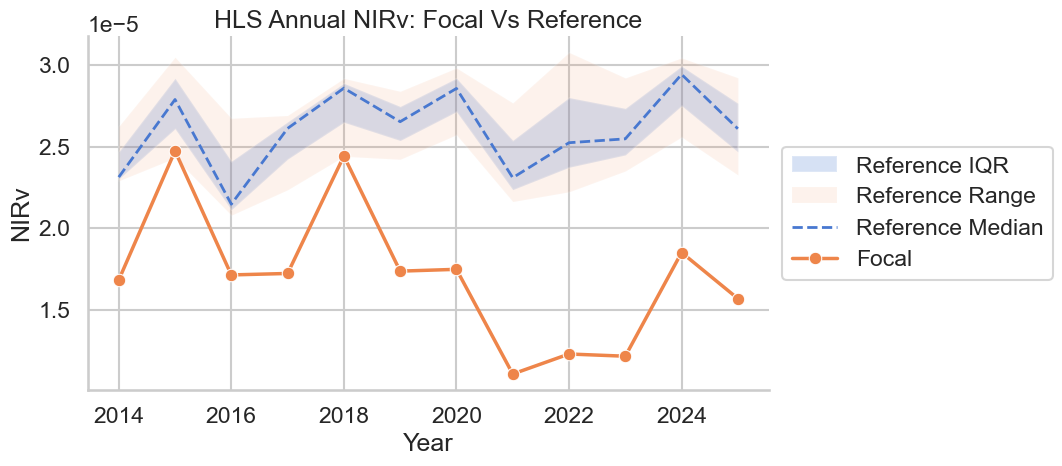

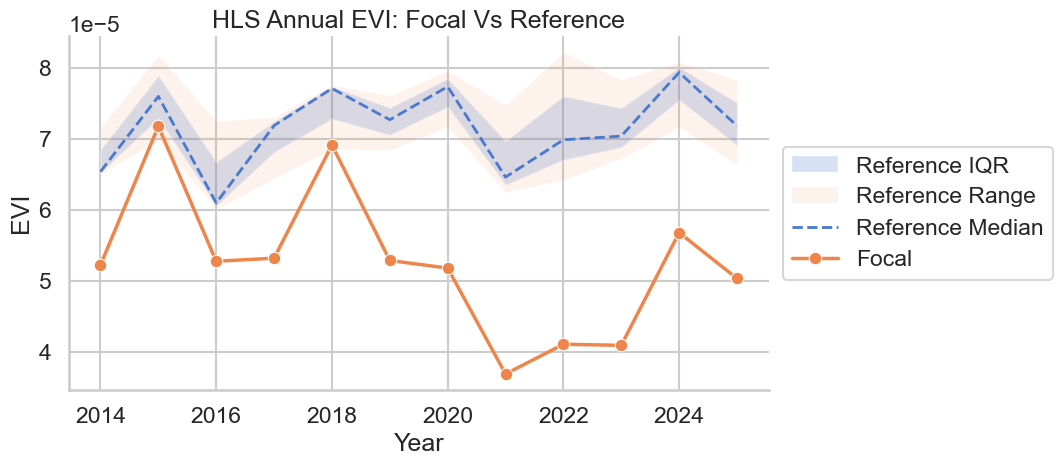

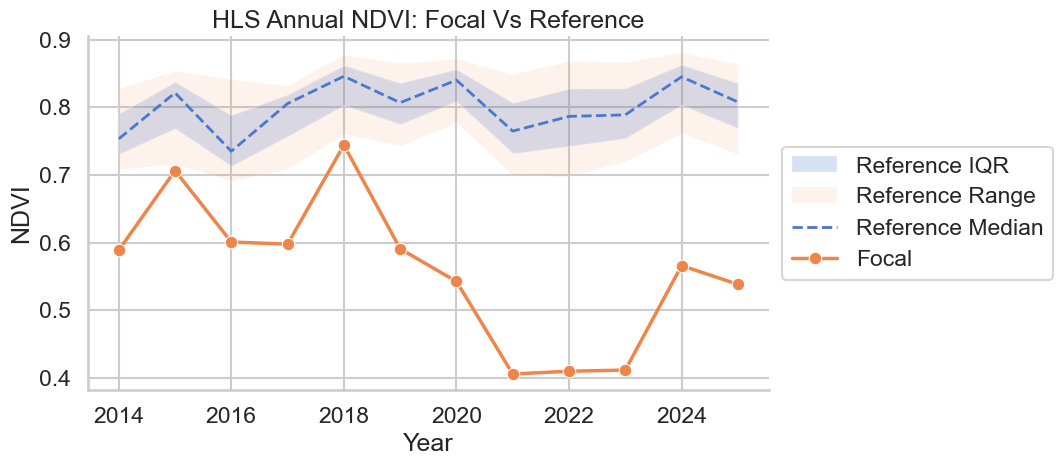

In [4]:
hls_annual_core_figs = plot_annual_productivity_core_figures(
    outputs=hls_annual_outputs,
    source_label="HLS",
    metric_cols=PRODUCTIVITY_METRICS,
)

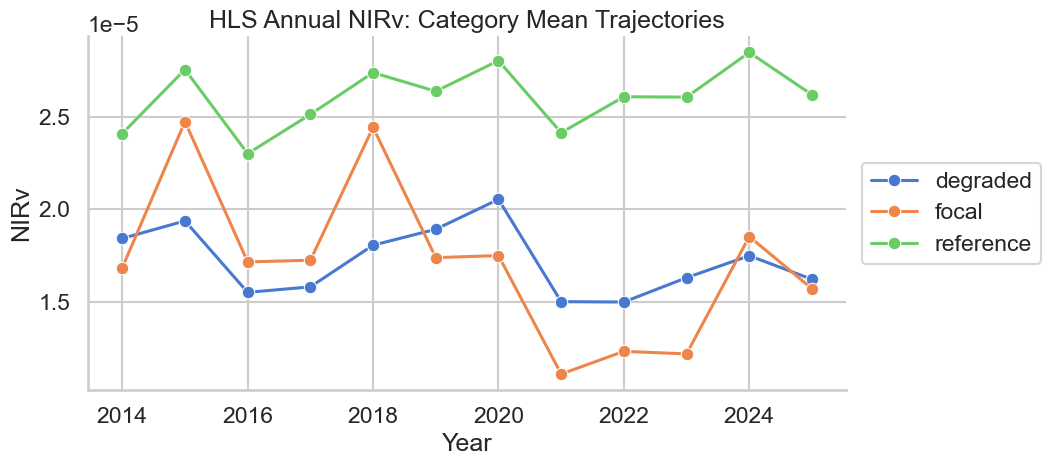

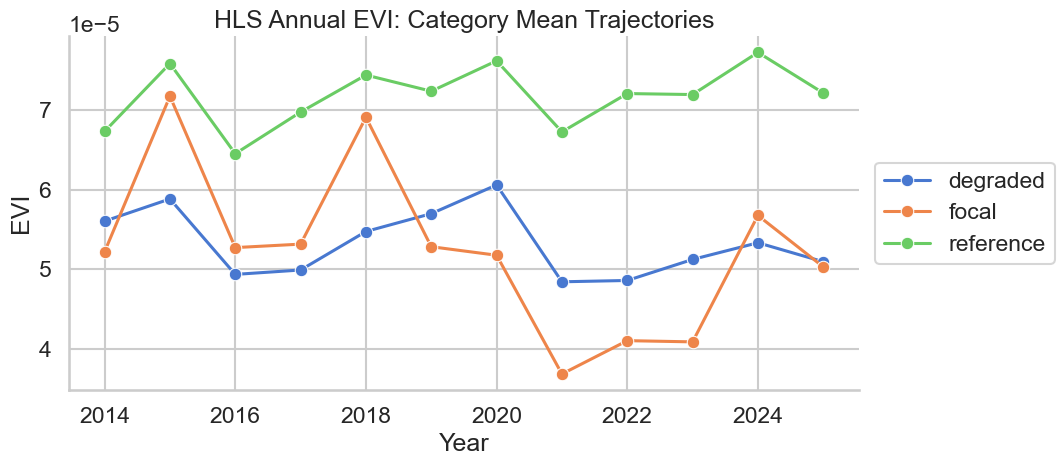

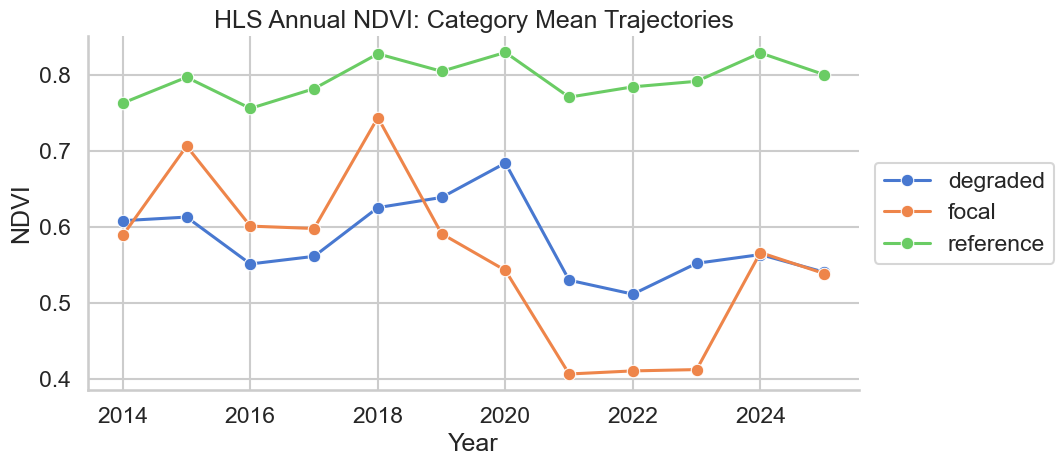

In [5]:
hls_annual_category_figs = plot_annual_productivity_category_figures(
    outputs=hls_annual_outputs,
    source_label="HLS",
    metric_cols=PRODUCTIVITY_METRICS,
)

#### HLS annual focal vs degraded NIRv

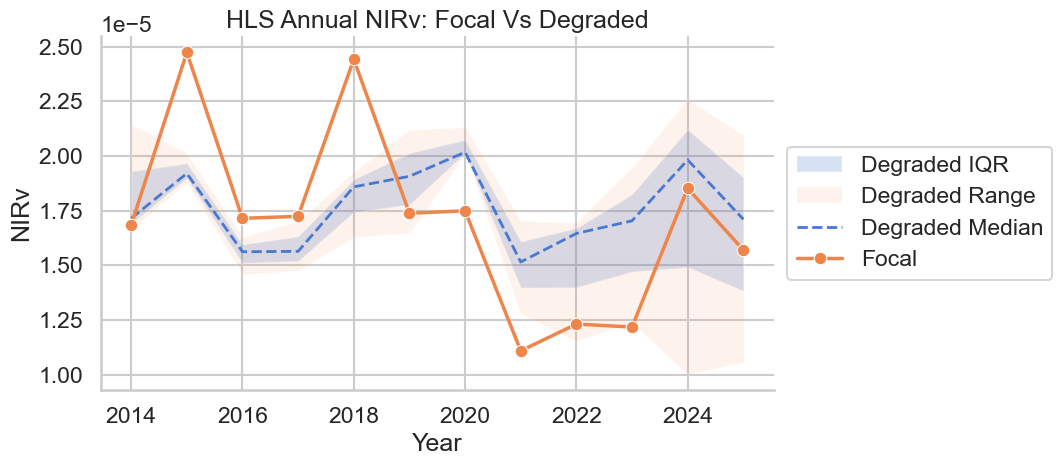

In [6]:
from tgbs_rs.plotting.timeseries_plots import set_plot_theme, plot_focal_vs_envelope
from tgbs_rs.plotting.figure_specs import make_annual_title, get_metric_label

set_plot_theme()

fig, ax = plot_focal_vs_envelope(
    comparison_df=hls_annual_outputs["focal_vs_degraded"],
    metric_col="NIRv",
    envelope_label="degraded",
    title=make_annual_title(
        metric_col="NIRv",
        comparison_label="Focal Vs Degraded",
        source_label="HLS",
    ),
    ylabel=get_metric_label("NIRv"),
)

##### Build Sentinel-2 Outputs

In [7]:
s2_annual_outputs = run_annual_productivity_workflow(
    annual_df=s2_annual_df,
    metric_cols=PRODUCTIVITY_METRICS,
)

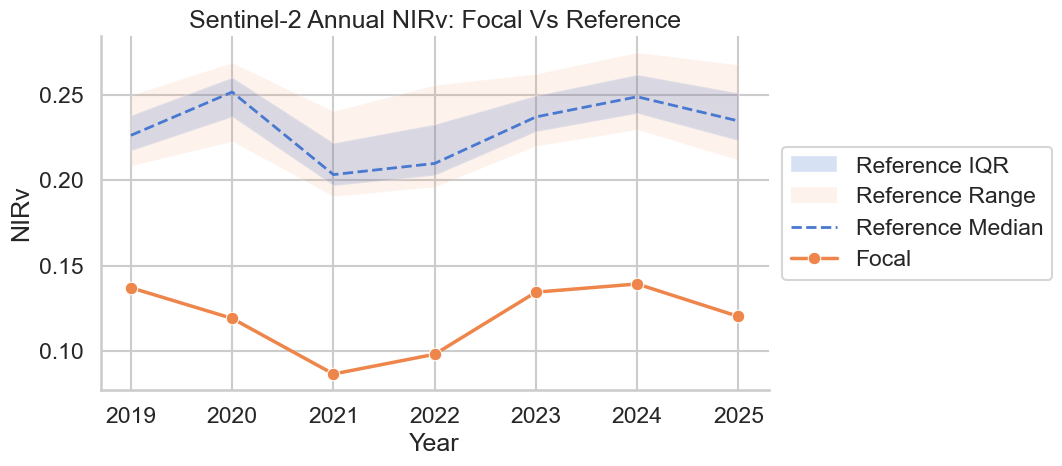

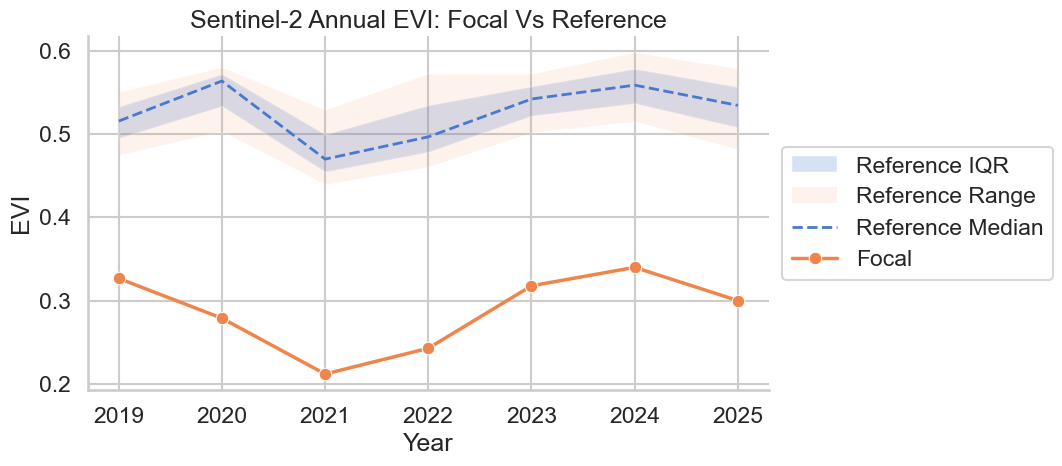

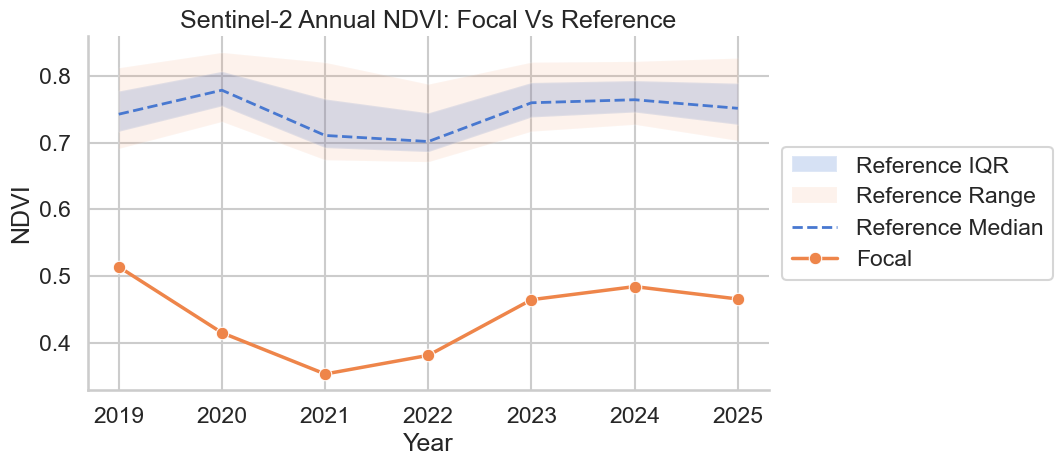

In [8]:
s2_annual_core_figs = plot_annual_productivity_core_figures(
    outputs=s2_annual_outputs,
    source_label="Sentinel-2",
    metric_cols=PRODUCTIVITY_METRICS,
)

##### Build the HLS wet-season productivity outputs

In [9]:
hls_wet_outputs = run_single_season_productivity_workflow(
    seasonal_df=hls_seasonal_df,
    season="wet",
    metric_cols=SEASONAL_CORE_METRICS,
)

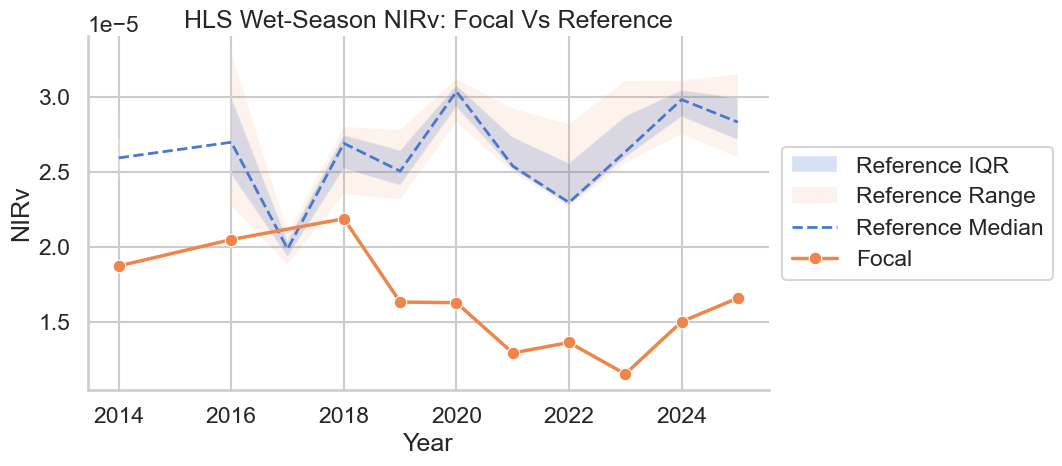

In [10]:
hls_wet_figs = plot_single_season_core_figures(
    outputs=hls_wet_outputs,
    season="wet",
    source_label="HLS",
    metric_cols=["NIRv"],
)

##### Build the HLS dry-season productivity outputs

In [11]:
hls_dry_outputs = run_single_season_productivity_workflow(
    seasonal_df=hls_seasonal_df,
    season="dry",
    metric_cols=SEASONAL_CORE_METRICS,
)

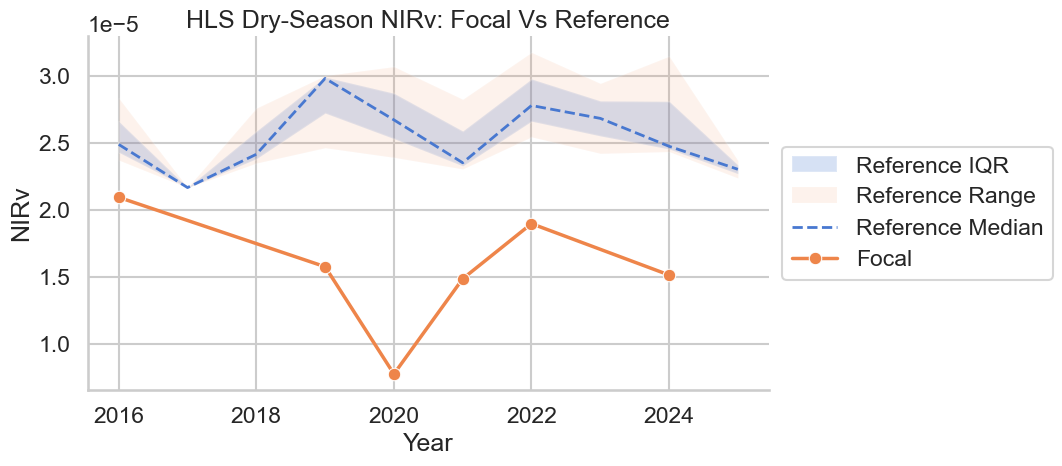

In [12]:
hls_dry_figs = plot_single_season_core_figures(
    outputs=hls_dry_outputs,
    season="dry",
    source_label="HLS",
    metric_cols=["NIRv"],
)